In [3]:
import sparqldataframe as sdf

In [4]:
sparql_endpoint="https://publications.europa.eu/webapi/rdf/sparql"

In [5]:
#copy the required query from the query library (explore tab in the TED open data service)
notices_per_month_query = """
PREFIX epo: <http://data.europa.eu/a4g/ontology#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>

SELECT ?month (COUNT(DISTINCT ?publicationNumber) AS ?numberOfNotices)
WHERE {
  FILTER (?publicationDate >= "2024-01-01"^^xsd:date &&
          ?publicationDate <= "2026-03-31"^^xsd:date)

  GRAPH ?g {
    ?notice a epo:Notice ;
            epo:hasPublicationDate ?publicationDate ;
            epo:hasNoticePublicationNumber ?publicationNumber .

    BIND(SUBSTR(STR(?publicationDate), 1, 7) AS ?month)
  }
}
GROUP BY ?month
ORDER BY ?month
"""

In [6]:
month_count = sdf.query(sparql_endpoint,notices_per_month_query)
display(month_count)

,month,numberOfNotices
0,2024-01,40406
1,2024-02,57919
2,2024-03,64613
3,2024-04,67098
4,2024-05,62462
5,2024-06,62652
6,2024-07,74954
7,2024-08,60874
8,2024-09,64741
9,2024-10,78224


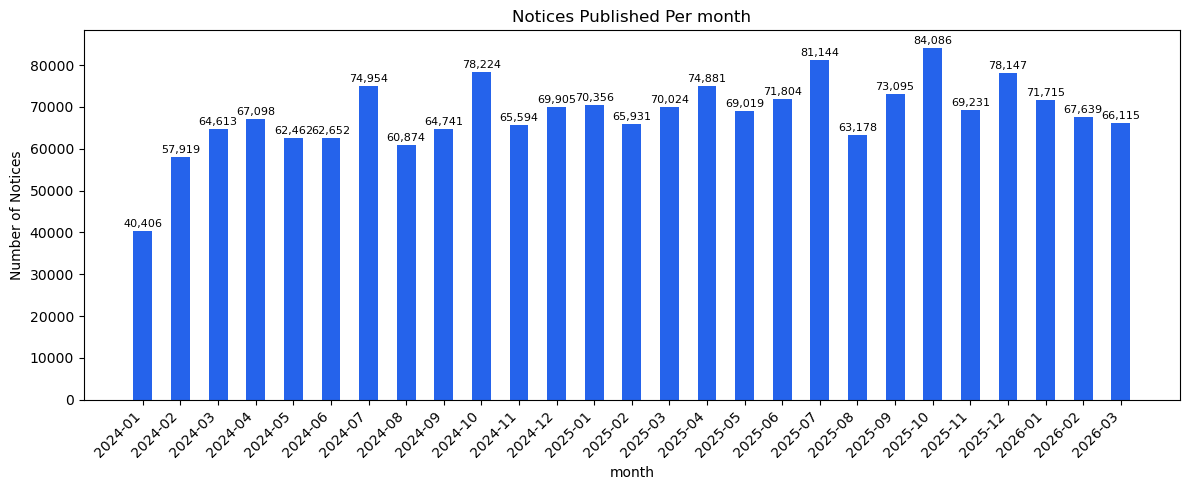

In [59]:
import matplotlib.pyplot as plt
month_count['numberOfNotices'] = month_count['numberOfNotices'].astype(int)

plt.figure(figsize=(12, 5))
bars = plt.bar(month_count['month'], month_count['numberOfNotices'], color='#2563eb', width=0.5)
plt.xlabel('month')
plt.ylabel('Number of Notices')
plt.title('Notices Published Per month')
#plt.xticks(month_count['month'])
plt.xticks(month_count['month'], rotation=45, ha='right')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()